Loaded counterfactual data from Counterfactual\counterfactual_forcal.csv


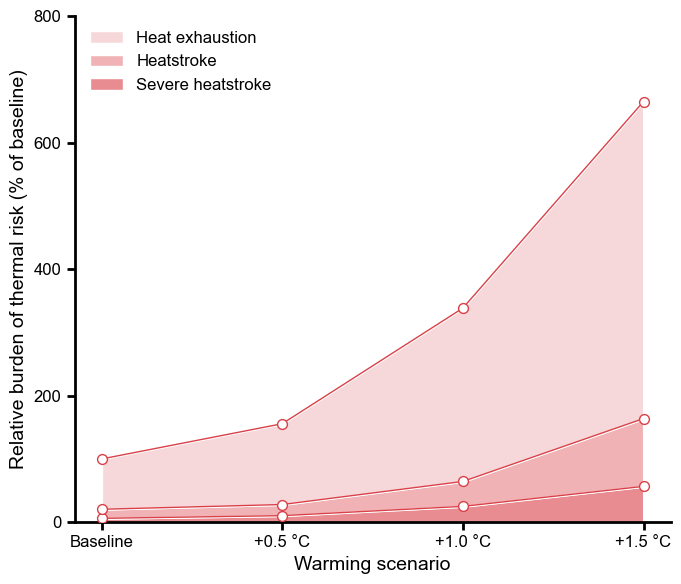

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
import re

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.linewidth': 2,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,
    'lines.solid_capstyle': 'round',
})

def hex_to_rgba(hex_color, alpha=1.0):
    hex_color = hex_color.lstrip('#')
    r, g, b = [int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4)]
    return (r, g, b, alpha)

COLORS = {
    'exhaust': {'fill': hex_to_rgba('#DA4048', 0.2), 'line': '#DA4048', 'edge': 'white'},
    'stroke': {'fill': hex_to_rgba('#DA4048', 0.4), 'line': '#DA4048', 'edge': 'white'},
    'severe': {'fill': hex_to_rgba('#DA4048', 0.6), 'line': '#DA4048', 'edge': 'white'},
}

save_dir = Path('MainFigures')
save_dir.mkdir(parents=True, exist_ok=True)

scenario_order = [0.0, 0.5, 1.0, 1.5]
scenario_labels = {0.0: 'Baseline', 0.5: '+0.5 °C', 1.0: '+1.0 °C', 1.5: '+1.5 °C'}

def parse_warming_header(value):
    if pd.isna(value):
        return None
    text = str(value).strip()
    if not text:
        return None
    if text.lower() == 'baseline':
        return 0.0
    match = re.search(r'\d+(?:\.\d+)?', text)
    return float(match.group(0)) if match else None

def load_template_counterfactual(path):
    raw_cf = pd.read_excel(path, header=None)
    records = []
    current_trise = None

    for col in range(1, raw_cf.shape[1]):
        parsed_header = parse_warming_header(raw_cf.iloc[0, col])
        if parsed_header is not None:
            current_trise = parsed_header

        rest_rate = pd.to_numeric(raw_cf.iloc[1, col], errors='coerce')
        if current_trise is None or pd.isna(rest_rate):
            continue

        values = pd.to_numeric(raw_cf.iloc[2:, col], errors='coerce').dropna()
        for value in values:
            records.append({
                'CoreTempRise': value,
                'T_rise': current_trise,
                'MandatoryRestRate': float(rest_rate),
                'MaxWorkShare': 1.0 - float(rest_rate),
            })

    return pd.DataFrame(records)

def load_long_counterfactual(path):
    data = pd.read_csv(path, encoding='utf-8-sig')
    required = {'CoreTempRise', 'T_rise', 'MaxWorkShare'}
    missing = required - set(data.columns)
    if missing:
        raise KeyError(f'{path} missing columns: {sorted(missing)}')
    data = data[['CoreTempRise', 'T_rise', 'MaxWorkShare']].copy()
    data['MandatoryRestRate'] = 1.0 - data['MaxWorkShare']
    return data

counterfactual_dir = Path('Counterfactual')
template_candidates = [
    counterfactual_dir / 'counterfactual_for_understand.xlsx',
]
long_csv = counterfactual_dir / 'counterfactual_forcal.csv'

for candidate in template_candidates:
    if candidate.exists():
        cf = load_template_counterfactual(candidate)
        print(f'Loaded counterfactual data from {candidate}')
        break
else:
    cf = load_long_counterfactual(long_csv)
    print(f'Loaded counterfactual data from {long_csv}')

cf['T_rise'] = pd.to_numeric(cf['T_rise'], errors='coerce')
cf['CoreTempRise'] = pd.to_numeric(cf['CoreTempRise'], errors='coerce')
cf['MandatoryRestRate'] = pd.to_numeric(cf['MandatoryRestRate'], errors='coerce').round(2)
cf['MaxWorkShare'] = pd.to_numeric(cf['MaxWorkShare'], errors='coerce')
cf = cf.dropna(subset=['CoreTempRise', 'T_rise', 'MandatoryRestRate', 'MaxWorkShare'])
cf = cf[cf['T_rise'].isin(scenario_order)]

no_intervention = cf[np.isclose(cf['MandatoryRestRate'], 0.0)].copy()

risk_counts = []
for trise in scenario_order:
    values = no_intervention[np.isclose(no_intervention['T_rise'], trise)]['CoreTempRise']
    risk_counts.append({
        'T_rise': trise,
        'Heat exhaustion': ((values > 1.5) & (values < 3.5)).sum(),
        'Heatstroke': ((values > 3.5) & (values < 5.0)).sum(),
        'Severe heatstroke': (values > 5.0).sum(),
    })

risk_df = pd.DataFrame(risk_counts)
baseline_total = risk_df.loc[np.isclose(risk_df['T_rise'], 0.0), ['Heat exhaustion', 'Heatstroke', 'Severe heatstroke']].sum(axis=1).iloc[0]
if baseline_total == 0:
    raise ValueError('Baseline thermal-risk count is zero; Fig4A percentages cannot be computed.')

exhaustion_pct = risk_df['Heat exhaustion'].to_numpy() / baseline_total * 100
heatstroke_pct = risk_df['Heatstroke'].to_numpy() / baseline_total * 100
severe_pct = risk_df['Severe heatstroke'].to_numpy() / baseline_total * 100

temp_increase = np.array(scenario_order)
y1 = severe_pct
y2 = severe_pct + heatstroke_pct
y3 = severe_pct + heatstroke_pct + exhaustion_pct

fig, ax = plt.subplots(figsize=(7, 6))
ax.fill_between(temp_increase, 0, y1, color=COLORS['severe']['fill'], edgecolor=COLORS['severe']['edge'], linewidth=1.5, label='Severe heatstroke')
ax.fill_between(temp_increase, y1, y2, color=COLORS['stroke']['fill'], edgecolor=COLORS['stroke']['edge'], linewidth=1.5, label='Heatstroke')
ax.fill_between(temp_increase, y2, y3, color=COLORS['exhaust']['fill'], edgecolor=COLORS['exhaust']['edge'], linewidth=1.5, label='Heat exhaustion')

ax.plot(temp_increase, y1, color=COLORS['severe']['line'], linewidth=1)
ax.plot(temp_increase, y2, color=COLORS['stroke']['line'], linewidth=1)
ax.plot(temp_increase, y3, color=COLORS['exhaust']['line'], linewidth=1)

ax.scatter(temp_increase, y1, color='white', edgecolor=COLORS['severe']['line'], s=50, zorder=5)
ax.scatter(temp_increase, y2, color='white', edgecolor=COLORS['stroke']['line'], s=50, zorder=5)
ax.scatter(temp_increase, y3, color='white', edgecolor=COLORS['exhaust']['line'], s=50, zorder=5)

ax.set_xticks(temp_increase)
ax.set_xticklabels([scenario_labels[x] for x in scenario_order])
ax.set_xlabel('Warming scenario')
ax.set_ylabel('Relative burden of thermal risk (% of baseline)')

y_tick_step = 200
y_max = max(y3) * 1.15 if max(y3) > 0 else y_tick_step
y_max = np.ceil(y_max / y_tick_step) * y_tick_step
ax.set_ylim(0, y_max)
ax.set_yticks(np.arange(0, y_max + y_tick_step, y_tick_step))

legend_elements = [
    Patch(facecolor=COLORS['exhaust']['fill'], edgecolor='white', label='Heat exhaustion'),
    Patch(facecolor=COLORS['stroke']['fill'], edgecolor='white', label='Heatstroke'),
    Patch(facecolor=COLORS['severe']['fill'], edgecolor='white', label='Severe heatstroke'),
]
ax.legend(handles=legend_elements, loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig(save_dir / 'Fig4a.tiff', dpi=600, format='tiff', bbox_inches='tight')
plt.show()


In [2]:
summary_records = []

for trise, group in cf.groupby('T_rise'):
    baseline = group[np.isclose(group['MandatoryRestRate'], 0.0)]
    if baseline.empty:
        continue

    baseline_heatstroke = ((baseline['CoreTempRise'] > 3.5) & (baseline['CoreTempRise'] < 5.0)).sum()
    baseline_severe = (baseline['CoreTempRise'] > 5.0).sum()

    for rest_rate, scenario in group.groupby('MandatoryRestRate'):
        if np.isclose(rest_rate, 0.0):
            continue

        heatstroke_count = ((scenario['CoreTempRise'] > 3.5) & (scenario['CoreTempRise'] < 5.0)).sum()
        severe_count = (scenario['CoreTempRise'] > 5.0).sum()
        max_work_share = 1.0 - rest_rate

        summary_records.append({
            'T_rise': trise,
            'MaxWorkShare': max_work_share,
            'MandatoryRestRate': rest_rate,
            'MandatoryRestPercent': rest_rate * 100,
            'Heatstroke avoided (%)': np.nan if baseline_heatstroke == 0 else (baseline_heatstroke - heatstroke_count) / baseline_heatstroke * 100,
            'Severe heatstroke avoided (%)': np.nan if baseline_severe == 0 else (baseline_severe - severe_count) / baseline_severe * 100,
        })

summary_columns = [
    'T_rise', 'MaxWorkShare', 'MandatoryRestRate', 'MandatoryRestPercent',
    'Heatstroke avoided (%)', 'Severe heatstroke avoided (%)'
]
summary_df = pd.DataFrame(summary_records, columns=summary_columns)
if not summary_df.empty:
    summary_df = summary_df.sort_values(['T_rise', 'MandatoryRestPercent'])
summary_df.head(25)


,T_rise,MaxWorkShare,MandatoryRestRate,MandatoryRestPercent,Heatstroke avoided (%),Severe heatstroke avoided (%)
0,0.0,0.95,0.05,5.0,22.727273,31.578947
1,0.0,0.90,0.10,10.0,31.818182,100.000000
2,0.0,0.85,0.15,15.0,68.181818,100.000000
3,0.0,0.80,0.20,20.0,100.000000,100.000000
4,0.0,0.75,0.25,25.0,100.000000,100.000000
5,0.5,0.95,0.05,5.0,14.814815,40.625000
6,0.5,0.90,0.10,10.0,38.888889,75.000000
7,0.5,0.85,0.15,15.0,50.000000,100.000000
8,0.5,0.80,0.20,20.0,88.888889,100.000000
9,0.5,0.75,0.25,25.0,100.000000,100.000000


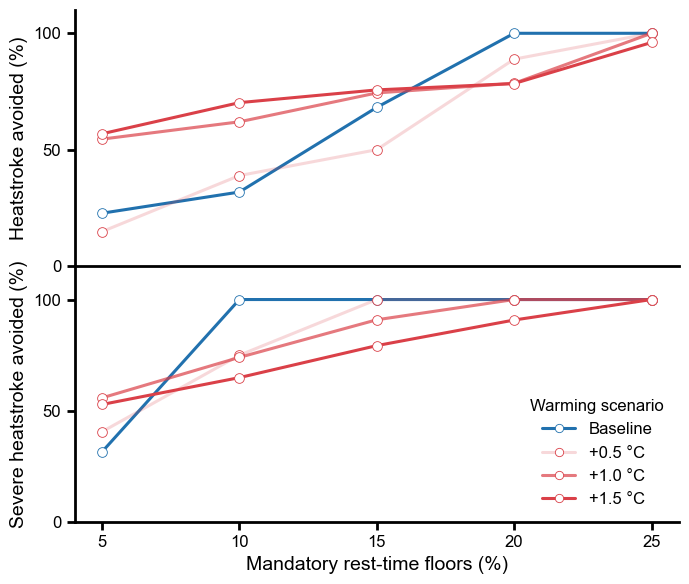

In [3]:
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.linewidth': 2,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,
    'lines.solid_capstyle': 'round',
})

SCENARIO_COLORS = {
    'Baseline': hex_to_rgba('#2171AE'),
    '+0.5 °C': hex_to_rgba('#DA4048', alpha=0.2),
    '+1.0 °C': hex_to_rgba('#DA4048', alpha=0.7),
    '+1.5 °C': hex_to_rgba('#DA4048'),
}

fig, axes = plt.subplots(2, 1, figsize=(7.5, 6), sharex=True, gridspec_kw={'hspace': 0})
marker_style = dict(marker='o', markersize=7, markerfacecolor='white', markeredgewidth=0.6)

for trise in scenario_order:
    scenario = summary_df[np.isclose(summary_df['T_rise'], trise)].sort_values('MandatoryRestPercent')
    label = scenario_labels[trise]
    color = SCENARIO_COLORS[label]
    axes[0].plot(scenario['MandatoryRestPercent'], scenario['Heatstroke avoided (%)'], color=color, linewidth=2.2, **marker_style)
    axes[1].plot(scenario['MandatoryRestPercent'], scenario['Severe heatstroke avoided (%)'], color=color, linewidth=2.2, **marker_style)

axes[0].set_ylabel('Heatstroke avoided (%)')
axes[0].set_ylim(0, 110)
axes[0].set_yticks(np.arange(0, 101, 50))
axes[0].spines['bottom'].set_visible(False)
axes[0].tick_params(axis='x', bottom=False, labelbottom=False)

axes[1].set_xlabel('Mandatory rest-time floors (%)')
axes[1].set_ylabel('Severe heatstroke avoided (%)')
axes[1].set_ylim(0, 115)
axes[1].set_xticks(np.arange(5, 26, 5))
axes[1].set_yticks(np.arange(0, 101, 50))
axes[1].spines['top'].set_visible(True)

legend_elements = [
    Line2D([0], [0], color=SCENARIO_COLORS[scenario_labels[t]], lw=2.2,
           marker='o', markerfacecolor='white', markeredgewidth=0.6, label=scenario_labels[t])
    for t in scenario_order
]
axes[1].legend(handles=legend_elements, loc='lower right', frameon=False, title='Warming scenario')

plt.tight_layout(rect=(0.06, 0, 1, 1))
plt.savefig(save_dir / 'Fig4b.tif', dpi=600, format='tiff', bbox_inches='tight')
plt.show()
